In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData

ex = ExperimentData()
ex.get_experiment_data('diesel', 'steam', 'CO')
ex.get_all_available_variations()

[('diesel', 'air', 'O2'),
 ('diesel', 'air', 'CO'),
 ('diesel', 'air', 'NO'),
 ('diesel', 'air', 'NO2'),
 ('diesel', 'air', 'NOx'),
 ('diesel', 'air', 'CO2'),
 ('diesel', 'air', 'SO2'),
 ('diesel', 'steam', 'O2'),
 ('diesel', 'steam', 'CO'),
 ('diesel', 'steam', 'NO'),
 ('diesel', 'steam', 'NO2'),
 ('diesel', 'steam', 'NOx'),
 ('diesel', 'steam', 'CO2'),
 ('diesel', 'steam', 'SO2'),
 ('crude_oil', 'steam', 'O2'),
 ('crude_oil', 'steam', 'CO'),
 ('crude_oil', 'steam', 'NO'),
 ('crude_oil', 'steam', 'NO2'),
 ('crude_oil', 'steam', 'NOx'),
 ('crude_oil', 'steam', 'CO2'),
 ('crude_oil', 'steam', 'SO2'),
 ('heavy_oil', 'air', 'O2'),
 ('heavy_oil', 'air', 'CO'),
 ('heavy_oil', 'air', 'NO'),
 ('heavy_oil', 'air', 'NOx'),
 ('heavy_oil', 'air', 'CO2'),
 ('heavy_oil', 'air', 'SO2'),
 ('heavy_oil', 'steam', 'O2'),
 ('heavy_oil', 'steam', 'CO'),
 ('heavy_oil', 'steam', 'NO'),
 ('heavy_oil', 'steam', 'NOx'),
 ('heavy_oil', 'steam', 'CO2'),
 ('heavy_oil', 'steam', 'SO2'),
 ('kerosene', 'air', 'O2'),

In [2]:
variants = ex.get_all_available_variations()

surfs = {}
for var in [var for var in variants if var[2] == 'CO']:
    name = '_'.join(var)
    ex.get_experiment_data(*var)
    surface = ex.get_rbf_data()[2]
    surfs[name] = surface


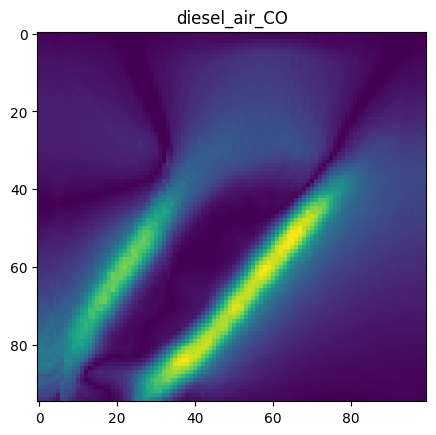

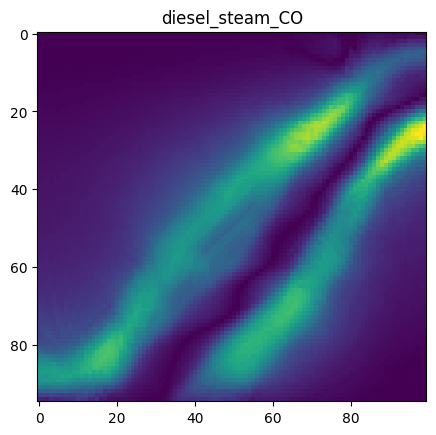

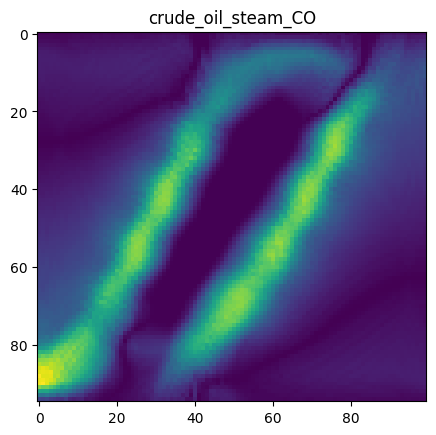

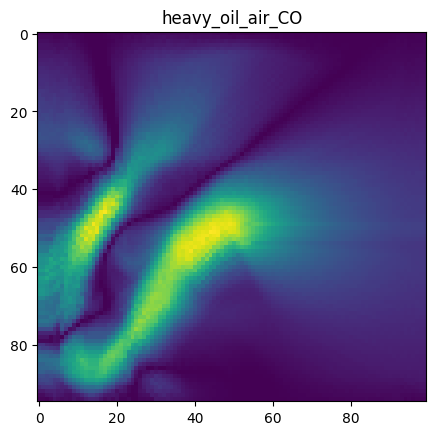

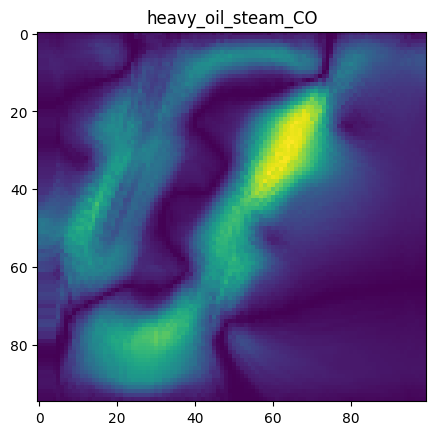

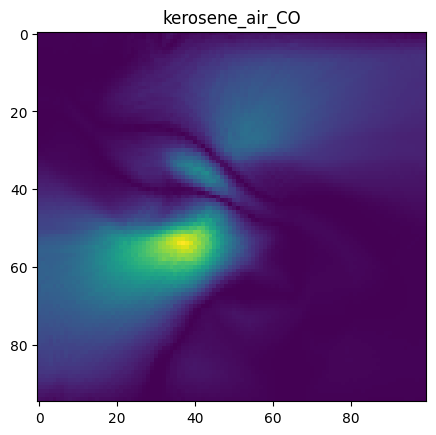

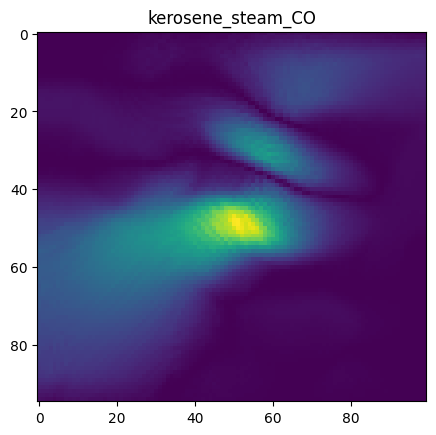

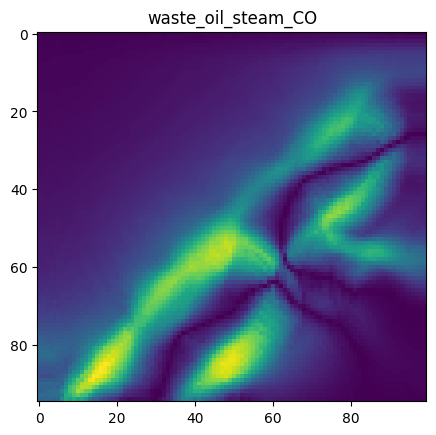

In [3]:
for surf in surfs:
    diff = np.abs(surfs[surf][5:] - surfs[surf][:-5])
    plt.imshow(diff)
    plt.title(surf)
    plt.show()
    plt.close()

In [28]:
opt_eqs = {}


for surf in surfs:
    flag = 0
    diff = np.abs(surfs[surf][5:] - surfs[surf][:-5])
    x = []
    y = []
    
    for i, row in enumerate(diff):
        for k, val in enumerate(row):
            if val > 120 and flag == 0:
                flag = 1
            elif val < 5 and flag == 1:
                flag = 2
            elif val > 120 and flag == 2:
                x.append(k)
                y.append(i)
                flag = 0
    opt_eqs[surf] = x, y
    flag = 0


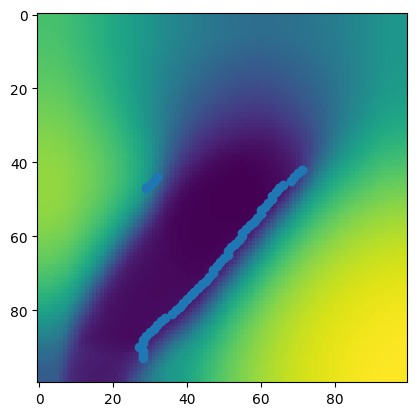

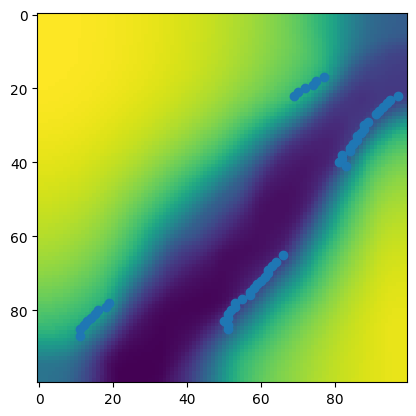

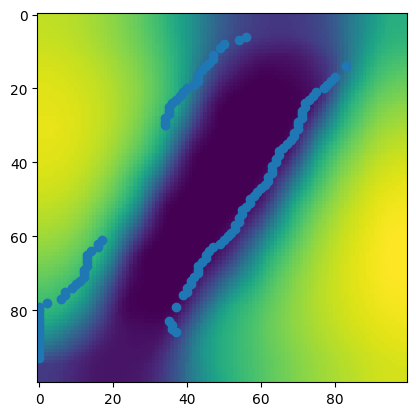

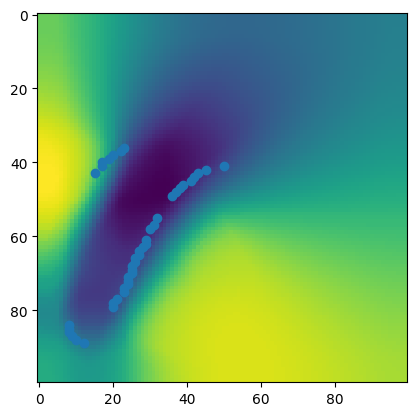

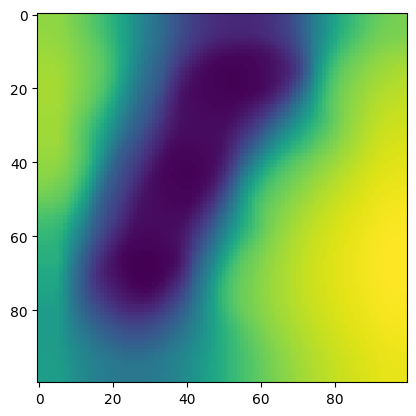

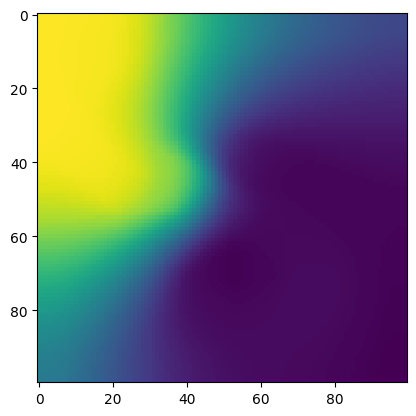

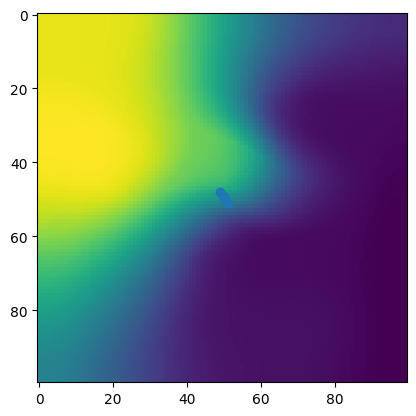

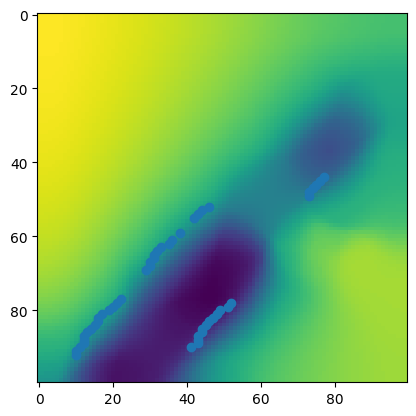

In [29]:
for surf in surfs:
    x, y = opt_eqs[surf]
    plt.scatter(x, y)
    plt.imshow(surfs[surf])
    plt.show()
    plt.close()